In [11]:
import os

train_path = "/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images"
train_csv  = "/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv"

In [12]:
val_path = "/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images"
val_csv  = "/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv"

In [13]:
import pandas as pd

val_df = pd.read_csv(val_csv)

print(val_df.head())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [14]:
import pandas as pd

train_df = pd.read_csv(train_csv)
print(train_df.head())

        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0


In [15]:
print("Total Images:", len(os.listdir(train_path)))
print("CSV Entries:", len(train_df))

Total Images: 2930
CSV Entries: 2930


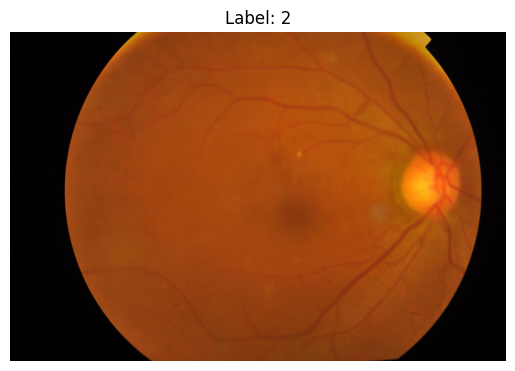

In [16]:
import cv2
import matplotlib.pyplot as plt

img_name = train_df.iloc[0]['id_code']
img_path = os.path.join(train_path, img_name + ".png")

img = cv2.imread(img_path)

if img is None:
    print("Error:", img_path)
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Label: {train_df.iloc[0]['diagnosis']}")
    plt.axis("off")

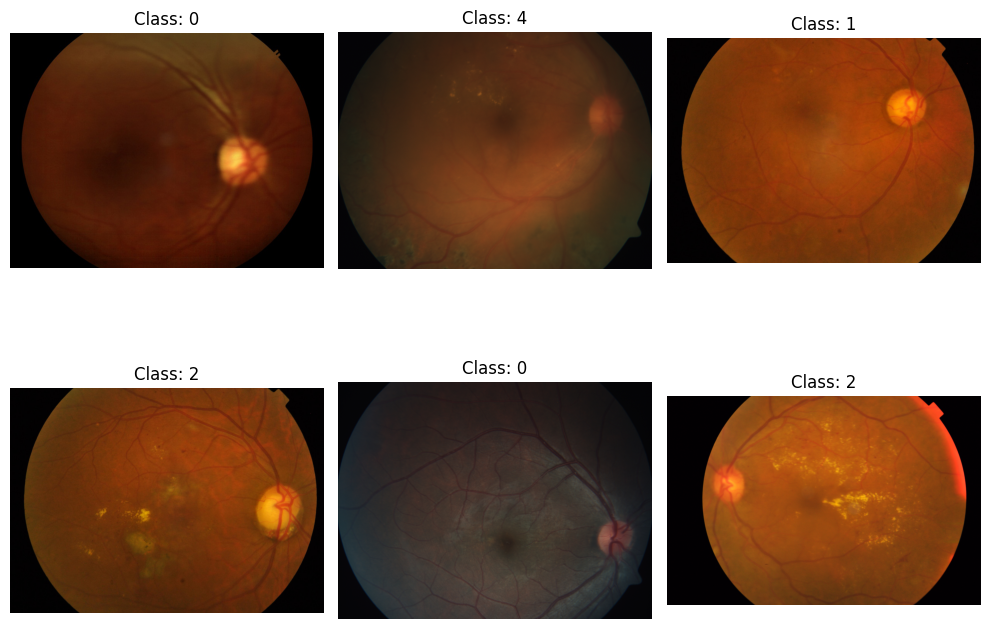

In [17]:
import random

plt.figure(figsize=(10,8))

for i in range(6):
    idx = random.randint(0, len(train_df)-1)
    img_name = train_df.iloc[idx]['id_code']
    label = train_df.iloc[idx]['diagnosis']
    
    img_path = os.path.join(train_path, img_name + ".png")
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.tight_layout()

Text(0.5, 1.0, 'Class Distribution')

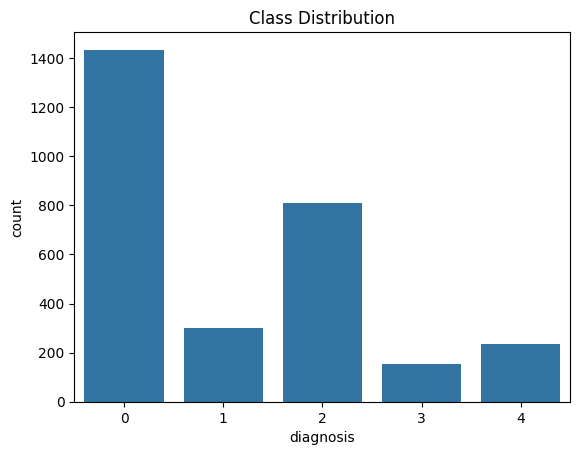

In [18]:
import seaborn as sns

sns.countplot(x=train_df['diagnosis'])
plt.title("Class Distribution")

In [19]:
print(train_df['diagnosis'].value_counts())

diagnosis
0    1434
2     808
1     300
4     234
3     154
Name: count, dtype: int64


In [20]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A

In [21]:
def crop_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)

    return img[y:y+h, x:x+w]

In [22]:
def ben_graham(img, sigma=10):
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blur, -4, 128)

In [23]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

In [24]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

In [25]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.Rotate(limit=10, p=0.5, border_mode=cv2.BORDER_REFLECT),

    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.1),

    A.Resize(224, 224),
])

In [26]:
def preprocess_and_augment(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    # 🔹 Preprocessing
    img = crop_image(img)
    img = ben_graham(img)
    img = apply_clahe(img)

    # 🔹 Augmentation
    augmented = train_transform(image=img)
    img = augmented['image']

    # 🔹 Normalize
    img = img / 255.0

    return img

In [27]:
def preprocess_only(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    img = crop_image(img)
    img = ben_graham(img)
    img = apply_clahe(img)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0

    return img

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

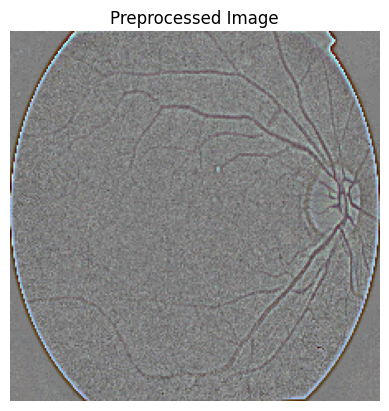

In [28]:
img_name = train_df.iloc[0]['id_code']
img_path = os.path.join(train_path, img_name + ".png")

img = preprocess_only(img_path)

plt.imshow(img)
plt.title("Preprocessed Image")
plt.axis("off")

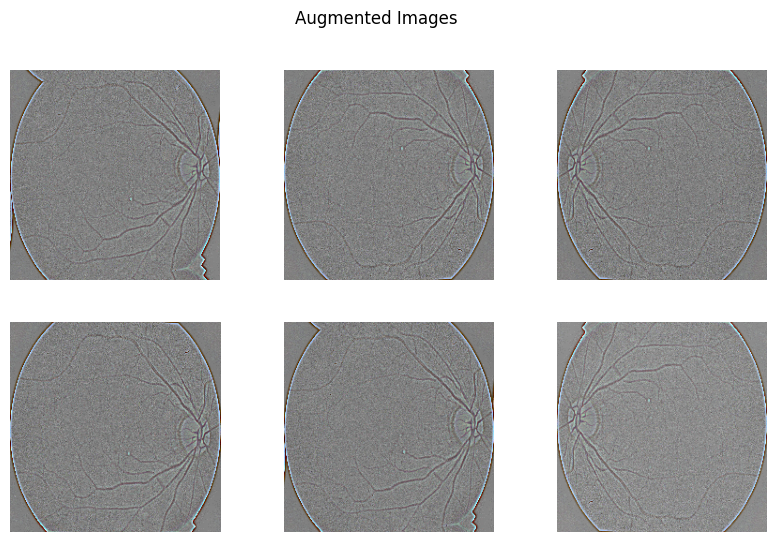

In [29]:
plt.figure(figsize=(10,6))

for i in range(6):
    img = preprocess_and_augment(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Augmented Images")
plt.show()

In [52]:
!pip install timm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import cohen_kappa_score

In [4]:
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform_fn):
        self.df = df
        self.img_dir = img_dir
        self.transform_fn = transform_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id_code']
        label = self.df.iloc[idx]['diagnosis']

        img_path = os.path.join(self.img_dir, img_name + ".png")

        img = self.transform_fn(img_path)

        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)

        return img, torch.tensor(label, dtype=torch.long)

In [30]:
train_dataset = DRDataset(train_df, train_path, preprocess_and_augment)
val_dataset   = DRDataset(val_df, val_path, preprocess_only)

In [31]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [5]:
class DRModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=0
        )

        # 🔥 Automatically get feature size
        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 5)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DRModel().to(device)

In [32]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(5),
    y=train_df['diagnosis'].values
)

weights = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [33]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [34]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [35]:
def evaluate(model, loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(predictions)
            targets.extend(labels.numpy())

    kappa = cohen_kappa_score(targets, preds, weights='quadratic')

    return kappa

In [ ]:
best_kappa = -1   # 🔥 fix

epochs = 30

for epoch in range(epochs):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_kappa = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation QWK: {val_kappa:.4f}")

    # ✅ Save BEST model
    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("✅ Best Model Saved!")

    # 🔥 ALWAYS SAVE (important)
    torch.save(model.state_dict(), "/kaggle/working/last_model.pth")

    scheduler.step()

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DRModel()
model.load_state_dict(torch.load("/kaggle/input/datasets/sufiyankhan7/diabetic-retinopathy-model/best_model.pth"))
model.to(device)
model.eval()

DRModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2

In [9]:
def predict_image(img_path):
    img = preprocess_only(img_path)

    img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        pred = torch.argmax(output, dim=1).item()

    return pred

In [36]:
img_name = val_df.iloc[0]['id_code']
img_path = os.path.join(val_path, img_name + ".png")

pred = predict_image(img_path)

print("Predicted Class:", pred)
print("Actual Class:", val_df.iloc[0]['diagnosis'])

Predicted Class: 2
Actual Class: 2


In [37]:
classes = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative"
}

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

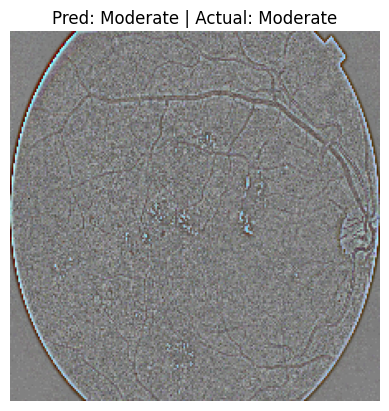

In [38]:
import matplotlib.pyplot as plt

img = preprocess_only(img_path)

plt.imshow(img)
plt.title(f"Pred: {classes[pred]} | Actual: {classes[val_df.iloc[0]['diagnosis']]}")
plt.axis("off")

In [39]:
from sklearn.metrics import accuracy_score, f1_score

all_preds = []
all_labels = []

for i in range(len(val_df)):
    img_name = val_df.iloc[i]['id_code']
    img_path = os.path.join(val_path, img_name + ".png")

    pred = predict_image(img_path)

    all_preds.append(pred)
    all_labels.append(val_df.iloc[i]['diagnosis'])

In [40]:
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nF1 Score:", f1_score(all_labels, all_preds, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

Accuracy: 0.7814207650273224

F1 Score: 0.7833087442059204

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       172
           1       0.57      0.85      0.68        40
           2       0.82      0.57      0.67       104
           3       0.33      0.45      0.38        22
           4       0.45      0.46      0.46        28

    accuracy                           0.78       366
   macro avg       0.63      0.66      0.63       366
weighted avg       0.81      0.78      0.78       366



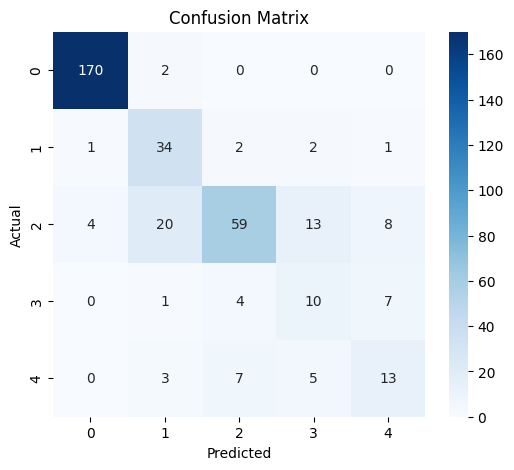

In [41]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [4]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 80.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=c4dc7acf19618b0fb11a8a7eb68c0346b86417d0112aef54df0a3a66e7178259
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [45]:
target_layer = model.backbone.conv_head

In [46]:
img = preprocess_only(img_path)

input_tensor = torch.tensor(img, dtype=torch.float32)\
    .permute(2,0,1)\
    .unsqueeze(0)\
    .to(device)

In [47]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor)[0]

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

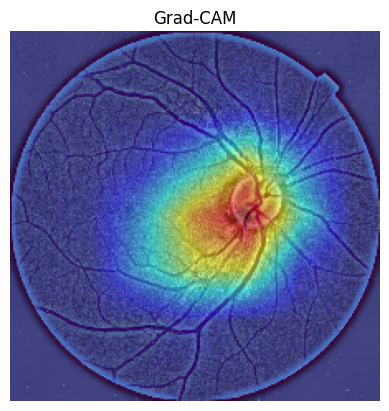

In [48]:
import numpy as np

visualization = show_cam_on_image(
    img.astype(np.float32),
    grayscale_cam,
    use_rgb=True
)

import matplotlib.pyplot as plt

plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

In [2]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 34.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: tomlkit
    Found existing installation: tomlkit 0.14.0
    Uninstalling tomlkit-0.14.0:
      Successfully uninstalled tomlkit-0.14.0
  Attempting uninstall: aiofiles
    Found existing installation: aiofiles 25.1.0
    Uninstalling aiofiles-25.1.0:
      Successfully uninstalled aiofiles-25.1.0

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import gradio as gr
import torch
import torch.nn as nn
import timm
import cv2
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ---------------- MODEL ---------------- #

class DRModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=False,
            num_classes=0
        )

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.backbone.num_features, 5)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

# ---------------- LOAD MODEL ---------------- #

device = torch.device("cpu")

model = DRModel()
model.load_state_dict(torch.load("/kaggle/input/datasets/sufiyankhan7/diabetic-retinopathy-model/best_model.pth", map_location=device))
model.to(device)
model.eval()

# ---------------- PREPROCESS ---------------- #

def preprocess_image(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Crop
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)
    img = img[y:y+h, x:x+w]

    # Ben Graham
    blur = cv2.GaussianBlur(img, (0, 0), 10)
    img = cv2.addWeighted(img, 4, blur, -4, 128)

    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(2.0, (8,8))
    cl = clahe.apply(l)
    img = cv2.merge((cl, a, b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)

    img = cv2.resize(img, (224, 224))
    img = img / 255.0

    return img

# ---------------- LABELS ---------------- #

classes = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

# ---------------- PREDICT + GRADCAM ---------------- #

def predict(img):
    original = img.copy()

    img = preprocess_image(img)

    tensor = torch.tensor(img, dtype=torch.float32)\
        .permute(2,0,1)\
        .unsqueeze(0)\
        .to(device)

    # ---- Prediction ---- #
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        confidence, pred = torch.max(probs, dim=1)

    top2 = torch.topk(probs, 2)

    pred1 = top2.indices[0][0].item()
    pred2 = top2.indices[0][1].item()

    conf1 = top2.values[0][0].item()
    conf2 = top2.values[0][1].item()
    

    # ---- Grad-CAM ---- #
    target_layer = model.backbone.conv_head

    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=tensor)[0]

    heatmap = show_cam_on_image(
        img.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    result = (
    f"1️⃣ {classes[pred1]} ({conf1:.2f})\n"
    f"2️⃣ {classes[pred2]} ({conf2:.2f})"
    )

    return result, heatmap

# ---------------- GRADIO UI ---------------- #

interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy"),
    outputs=[
        gr.Text(label="Prediction"),
        gr.Image(label="Grad-CAM Heatmap")
    ],
    title="Diabetic Retinopathy Detection",
    description="Upload a retina image to detect DR severity with explainability"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://20857dbc4675c56657.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
